# Breast Cancer Wisconsin (Diagnostic) Dataset Analysis

This notebook will guide you through the process of analyzing the Breast Cancer Wisconsin (Diagnostic) Dataset.

### **Steps:**
1.  **Data Loading and Initial Exploration:** Load the dataset, check for missing values, and understand its structure.
2.  **Data Preprocessing:** Handle categorical variables, prepare data for model training.
3.  **Model Building and Evaluation:** Implement and evaluate various classification models.

In [5]:
# Install opendatasets for downloading the dataset from Kaggle
%pip install opendatasets --quiet

In [6]:
import opendatasets as od
import pandas as pd

# Download the dataset from Kaggle
od.download('https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data')

# Load the dataset into a pandas DataFrame
df = pd.read_csv('breast-cancer-wisconsin-data/data.csv')

# Display the first 5 rows of the DataFrame
print('First 5 rows of the dataset:')
display(df.head())

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ok
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data


100%|██████████| 48.6k/48.6k [00:00<00:00, 1.54MB/s]


First 5 rows of the dataset:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [7]:
# Display information about the DataFrame
print('\nDataFrame Information:')
df.info()


DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  pe

### **Handling Missing Values and Unnecessary Columns**

In [8]:
# Drop the 'id' column and the 'Unnamed: 32' column as they are not useful for analysis
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True)

# Display the first 5 rows of the DataFrame after dropping columns
print('First 5 rows of the dataset after dropping columns:')
display(df.head())

# Display information about the DataFrame after dropping columns to confirm
print('\nDataFrame Information after dropping columns:')
df.info()

First 5 rows of the dataset after dropping columns:


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



DataFrame Information after dropping columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-

### **Visualize the Distribution of the Target Variable**

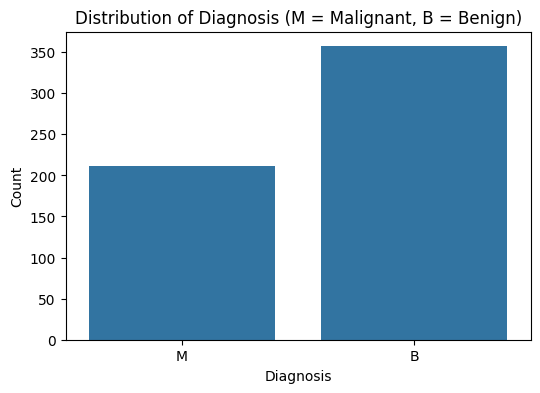

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a count plot to show the distribution of the 'diagnosis' column
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df)
plt.title('Distribution of Diagnosis (M = Malignant, B = Benign)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

### **Data Preprocessing: Encoding Categorical Target Variable**

In [10]:
# Count unique values in the 'diagnosis' column
print("Unique values in 'diagnosis' column and their counts:")
print(df['diagnosis'].value_counts())

# Encode the 'diagnosis' column: M=1 (Malignant), B=0 (Benign)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Display the first 5 rows of the DataFrame after encoding
print('\nFirst 5 rows of the dataset after encoding diagnosis:')
display(df.head())

Unique values in 'diagnosis' column and their counts:
diagnosis
B    357
M    212
Name: count, dtype: int64

First 5 rows of the dataset after encoding diagnosis:


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### **Data Preprocessing: Splitting Data into Training and Testing Sets**

In [11]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('diagnosis', axis=1) # All columns except 'diagnosis'
y = df['diagnosis']             # 'diagnosis' column

# Split the data into training and testing sets
# Using a 80/20 split and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Training features shape: (455, 30)
Testing features shape: (114, 30)
Training target shape: (455,)
Testing target shape: (114,)


### **Model Building: K-Nearest Neighbors (KNN)**

In [14]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the K-Nearest Neighbors model
knn_model = KNeighborsClassifier(n_neighbors=5) # Using 5 neighbors as a common starting point

# Train the model using the training data
knn_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test)

# Calculate and print the accuracy
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"K-Nearest Neighbors Accuracy: {accuracy_knn:.4f}")

K-Nearest Neighbors Accuracy: 0.9561


### **Model Building: Random Forest Classifier**

In [15]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest model
# Using 100 estimators as a common starting point
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model using the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Calculate and print the accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Classifier Accuracy: {accuracy_rf:.4f}")

Random Forest Classifier Accuracy: 0.9649


### **Model Building: Support Vector Machine (SVM)**

In [16]:
from sklearn.svm import SVC

# Initialize the Support Vector Machine model
# Using a linear kernel as a common starting point
svm_model = SVC(kernel='linear', random_state=42)

# Train the model using the training data
svm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test)

# Calculate and print the accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Support Vector Machine Accuracy: {accuracy_svm:.4f}")

Support Vector Machine Accuracy: 0.9561


### **Comparing Model Performance**

In [17]:
model_accuracies = {
    'Logistic Regression': accuracy_log_reg,
    'K-Nearest Neighbors': accuracy_knn,
    'Random Forest': accuracy_rf,
    'Support Vector Machine': accuracy_svm
}

# Sort models by accuracy in descending order
sorted_accuracies = sorted(model_accuracies.items(), key=lambda x: x[1], reverse=True)

print("\n--- Model Accuracies ---")
for model, accuracy in sorted_accuracies:
    print(f"{model}: {accuracy:.4f}")

print(f"\nThe best model is: {sorted_accuracies[0][0]} with an accuracy of {sorted_accuracies[0][1]:.4f}")


--- Model Accuracies ---
Random Forest: 0.9649
Logistic Regression: 0.9561
K-Nearest Neighbors: 0.9561
Support Vector Machine: 0.9561

The best model is: Random Forest with an accuracy of 0.9649


### **Model Building: Logistic Regression**

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize the Logistic Regression model
# Increased max_iter to ensure convergence
log_reg_model = LogisticRegression(random_state=42, max_iter=1000)

# Train the model using the training data
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Calculate and print the accuracy
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")

Logistic Regression Accuracy: 0.9561


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
